Initial combined shape: (13600, 14)
After cleaning: (5550, 20)

AUCs by class:
  0: 0.843
  1: 0.698
  2: 0.952

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.73      0.76       797
         1.0       0.46      0.50      0.48       401
         2.0       0.66      0.80      0.72       190

    accuracy                           0.67      1388
   macro avg       0.64      0.68      0.66      1388
weighted avg       0.68      0.67      0.68      1388


Mean predicted probabilities by true A1C class:
      P_prediab    P_diab
true                     
0.0    0.348977  0.088899
1.0    0.420856  0.232021
2.0    0.301894  0.620381


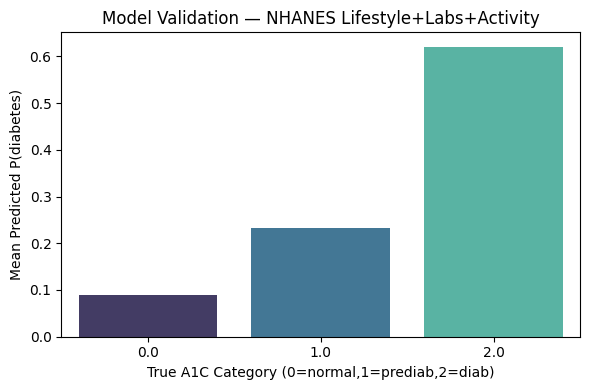


Spearman correlation between A1C category and predicted diabetes prob: r=1.000, p=0

✅ Saved nhanes_diabetes.joblib successfully.


In [ ]:
# NHANES Lifestyle + Labs + Activity Diabetes Risk Model

import pandas as pd, numpy as np, joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
import seaborn as sns, matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Helper to read .XPT (SAS transport) files
def read_xpt(p): 
    return pd.read_sas(p, format='xport')

# 1. Load 2017–2018 and 2021–2023 cycles
# A1C (label)
ghb_1718 = read_xpt("../data/nhanes/GHB_J.XPT")[["SEQN","LBXGH"]]
ghb_2123 = read_xpt("../data/nhanes/GHB_L.XPT")[["SEQN","LBXGH"]]

# Fasting glucose
glu_1718 = read_xpt("../data/nhanes/GLU_J.XPT")[["SEQN","LBXGLU"]]
glu_2123 = read_xpt("../data/nhanes/GLU_L.XPT")[["SEQN","LBXGLU"]]

# Demographics
demo_1718 = read_xpt("../data/nhanes/DEMO_J.XPT")[["SEQN","RIDAGEYR","RIAGENDR","RIDRETH3"]]
demo_2123 = read_xpt("../data/nhanes/DEMO_L.XPT")[["SEQN","RIDAGEYR","RIAGENDR","RIDRETH3"]]

# BMI, Hypertension, Smoking
bmx_1718 = read_xpt("../data/nhanes/BMX_J.XPT")[["SEQN","BMXBMI"]]
bmx_2123 = read_xpt("../data/nhanes/BMX_L.XPT")[["SEQN","BMXBMI"]]
bpq_1718 = read_xpt("../data/nhanes/BPQ_J.XPT")[["SEQN","BPQ020"]]
bpq_2123 = read_xpt("../data/nhanes/BPQ_L.XPT")[["SEQN","BPQ020"]]
smq_1718 = read_xpt("../data/nhanes/SMQ_J.XPT")[["SEQN","SMQ020"]]
smq_2123 = read_xpt("../data/nhanes/SMQ_L.XPT")[["SEQN","SMQ020"]]

# Physical activity (different vars per cycle)
paq_1718 = read_xpt("../data/nhanes/PAQ_J.XPT")[["SEQN","PAQ605","PAQ620"]]
paq_2123 = read_xpt("../data/nhanes/PAQ_L.XPT")[["SEQN","PAD790Q","PAD810Q","PAD680"]]

# 2. Combine all into single dataset
df_1718 = (ghb_1718.merge(glu_1718, on="SEQN", how="left")
                     .merge(demo_1718, on="SEQN", how="left")
                     .merge(bmx_1718, on="SEQN", how="left")
                     .merge(bpq_1718, on="SEQN", how="left")
                     .merge(smq_1718, on="SEQN", how="left")
                     .merge(paq_1718, on="SEQN", how="left"))

df_2123 = (ghb_2123.merge(glu_2123, on="SEQN", how="left")
                     .merge(demo_2123, on="SEQN", how="left")
                     .merge(bmx_2123, on="SEQN", how="left")
                     .merge(bpq_2123, on="SEQN", how="left")
                     .merge(smq_2123, on="SEQN", how="left")
                     .merge(paq_2123, on="SEQN", how="left"))

df = pd.concat([df_1718, df_2123], ignore_index=True)

df = df.rename(columns={
    "LBXGH":"A1C", "LBXGLU":"GLU", "RIDAGEYR":"AGE", "RIAGENDR":"SEX",
    "BMXBMI":"BMI", "BPQ020":"HTN", "SMQ020":"SMOKE", "RIDRETH3":"RACE"
})

print("Initial combined shape:", df.shape)

# 3. Define target and map predictors
def a1c_band(a):
    if pd.isna(a): return np.nan
    if a < 5.7: return 0  # normal
    if a < 6.5: return 1  # prediabetes
    return 2              # diabetes
df["Y"] = df["A1C"].apply(a1c_band)

# Binary flags
df["SEX_MALE"] = (df["SEX"]==1).astype(int)
df["HTN_FLAG"] = df["HTN"].map({1:1, 2:0})
df["SMOKING_IDX"] = df["SMOKE"].map({1:1, 2:0})
df["RACE_CAT"] = df["RACE"]

# Physical activity flag
df["PA_ANY"] = np.where(
    (df.get("PAQ605",0)==1) | (df.get("PAQ620",0)==1) |
    (df.get("PAD790Q",0)>0) | (df.get("PAD810Q",0)>0) | (df.get("PAD680",0)==1),
    1, 0
)

# 4. Clean and restrict to adults with valid A1C
df = df[(df["AGE"] >= 20) & (df["AGE"] <= 80)]
features = ["AGE","BMI","SEX_MALE","HTN_FLAG","SMOKING_IDX","GLU","PA_ANY"]
df = df.dropna(subset=features + ["Y"])

print("After cleaning:", df.shape)

# 5. Split & train balanced logistic regression
X = df[features]
y = df["Y"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, multi_class="ovr", class_weight="balanced"))
])

pipe.fit(Xtr, ytr)

print("\nAUCs by class:")
for k in [0,1,2]:
    auc = roc_auc_score((yte==k).astype(int), pipe.predict_proba(Xte)[:,k])
    print(f"  {k}: {auc:.3f}")

print("\nClassification Report:\n", classification_report(yte, pipe.predict(Xte)))

# 6. Check monotonic probability trend
probs = pipe.predict_proba(Xte)
pred_df = pd.DataFrame(probs, columns=["P_normal","P_prediab","P_diab"])
pred_df["true"] = yte.values

mean_probs = pred_df.groupby("true")[["P_prediab","P_diab"]].mean()
print("\nMean predicted probabilities by true A1C class:")
print(mean_probs)

# 7. Visualize risk progression
plt.figure(figsize=(6,4))
sns.barplot(x=mean_probs.index, y=mean_probs["P_diab"], palette="mako")
plt.ylabel("Mean Predicted P(diabetes)")
plt.xlabel("True A1C Category (0=normal,1=prediab,2=diab)")
plt.title("Model Validation — NHANES Lifestyle+Labs+Activity")
plt.tight_layout()
plt.show()

# 8. Spearman correlation (risk vs. true class)
r, p = spearmanr(mean_probs.index, mean_probs["P_diab"])
print(f"\nSpearman correlation between A1C category and predicted diabetes prob: r={r:.3f}, p={p:.3g}")

# 9. Save model
joblib.dump(pipe, "../models/nhanes_diabetes.joblib")
print("\n✅ Saved nhanes_diabetes.joblib successfully.")


In [ ]:
# 10. Export feature importance (standardized coefficients)
import json
import numpy as np

# Extract trained logistic regression coefficients
clf = pipe.named_steps["clf"]
scaler = pipe.named_steps["scale"]

feature_names = X.columns.tolist()

# Compute the average absolute coefficient importance across all classes
importance = np.mean(np.abs(clf.coef_), axis=0)

# Normalize to percentage
importance_percent = 100 * importance / np.sum(importance)

# Combine into readable structure
importance_data = [
    {"feature": f, "importance_percent": float(round(p, 2))}
    for f, p in zip(feature_names, importance_percent)
]

# Sort descending
importance_data = sorted(importance_data, key=lambda x: x["importance_percent"], reverse=True)

# Save to JSON
out_path = Path("../models/gluco_risk_feature_importance.json")
with open(out_path, "w") as f:
    json.dump(importance_data, f, indent=2)

print(f"\nSaved feature importance to {out_path}")
for item in importance_data:
    print(f"{item['feature']:<15} {item['importance_percent']:>6.2f}%")



✅ Saved feature importance to ..\models\gluco_risk_feature_importance.json
GLU              56.91%
AGE              20.95%
BMI              10.91%
HTN_FLAG          4.39%
PA_ANY            3.63%
SEX_MALE          1.94%
SMOKING_IDX       1.28%


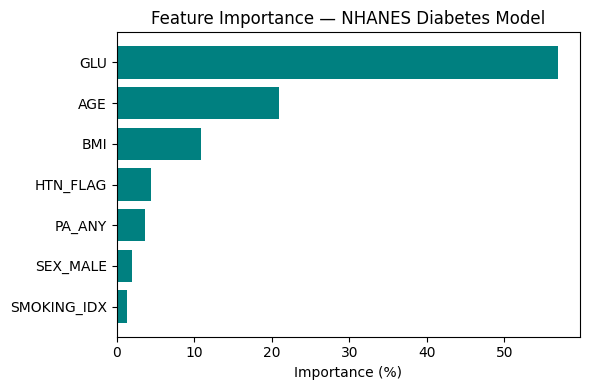

In [7]:
plt.figure(figsize=(6, 4))
plt.barh([x["feature"] for x in importance_data[::-1]],
         [x["importance_percent"] for x in importance_data[::-1]],
         color="teal")
plt.xlabel("Importance (%)")
plt.title("Feature Importance — NHANES Diabetes Model")
plt.tight_layout()
plt.show()


In [ ]:
import joblib
model = joblib.load("../models/nhanes_diabetes.joblib")
print(model.named_steps["scale"].feature_names_in_)


['AGE' 'BMI' 'SEX_MALE' 'HTN_FLAG' 'SMOKING_IDX' 'GLU' 'PA_ANY']


In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
# import save_onnx_model from onnx
import joblib, numpy as np
from sklearn.linear_model import LogisticRegression
import onnx # Import the onnx library

# Load model
model = joblib.load("../models/nhanes_diabetes.joblib")
scaler = model.named_steps["scale"]
clf = model.named_steps["clf"]

# Collapse scaler math into linear coefficients
W = clf.coef_ / scaler.scale_
b = clf.intercept_ - np.sum((clf.coef_ * scaler.mean_) / scaler.scale_, axis=1)

# Create a clean LogisticRegression object with all metadata
simple_clf = LogisticRegression()
simple_clf.classes_ = clf.classes_
simple_clf.coef_ = W
simple_clf.intercept_ = b
simple_clf.n_features_in_ = 7
simple_clf.n_iter_ = np.array([1])  # required metadata

# Explicitly set ONNX input type
initial_type = [("float_input", FloatTensorType([None, 7]))]

onnx_model = convert_sklearn(simple_clf, initial_types=initial_type, target_opset=17, options={"zipmap": False} )

save_path = "../models/nhanes_diabetes.onnx"
# Use onnx.save to save the model
onnx.save(onnx_model, save_path)
print(f"✅ Exported simplified ONNX model to {save_path}")

In [ ]:
import onnxruntime as rt
import numpy as np

session = rt.InferenceSession("../models/nhanes_diabetes.onnx")
#session = rt.InferenceSession("../models/model_nhanes_simplified_fixed.onnx")

input_name = session.get_inputs()[0].name
output_names = [o.name for o in session.get_outputs()]
print("Inputs:", input_name)
print("Outputs:", output_names)

# 7 features example
#[AGE, BMI, SEX_MALE, HTN_FLAG, SMOKING_IDX, GLU, PA_ANY].
x = np.array([[20, 22, 1, 0, 0, 110, 0]], dtype=np.float32)

pred = session.run(None, {input_name: x})

print("Predicted probabilities:", pred)


Inputs: float_input
Outputs: ['label', 'probabilities']
Predicted probabilities: [array([0]), array([[0.9443647 , 0.04447773, 0.0111576 ]], dtype=float32)]
